In [ ]:
train_running=False

#Import Data

In [ ]:
import math
import random
from collections import Counter, defaultdict
from itertools import chain
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

from joblib import Parallel, delayed
from scipy.sparse import vstack

from sklearn.feature_extraction.text import  TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, TensorDataset

from tqdm import tqdm


from transformers import Trainer, TrainingArguments
from transformers import AutoTokenizer
from sklearn.metrics import precision_recall_curve

from transformers import AutoModelForSequenceClassification

In [ ]:
!pip install -U "datasets==3.6.0"

In [ ]:
from datasets import load_dataset

full_dataset = load_dataset("skeskinen/TinyStories-GPT4", split="train")
full_dataset = full_dataset.remove_columns([c for c in full_dataset.column_names if c not in ["story", "features"]])
assert len(full_dataset) == 2745100

splits = full_dataset.train_test_split(test_size=10000, seed=42, shuffle=True)

train_dataset = splits["train"]
test_dataset  = splits["test"]

assert len(train_dataset) == 2735100
assert len(test_dataset)  == 10000

assert train_dataset[0]["story"][:33] == "One day, a little girl named Lily"
assert train_dataset[0]["features"] == ["Dialogue", "Conflict"]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/554 [00:00<?, ?B/s]

(…)-00000-of-00008-c63ccd5d5290f4a1.parquet:   0%|          | 0.00/194M [00:00<?, ?B/s]

(…)-00001-of-00008-478199d8ac044910.parquet:   0%|          | 0.00/194M [00:00<?, ?B/s]

(…)-00002-of-00008-9b868f59be94d815.parquet:   0%|          | 0.00/194M [00:00<?, ?B/s]

...

(…)-00004-of-00008-5f8ac0bb66de5834.parquet:   0%|          | 0.00/194M [00:00<?, ?B/s]

(…)-00005-of-00008-e8c22c3e776b87dd.parquet:   0%|          | 0.00/194M [00:00<?, ?B/s]

(…)-00006-of-00008-941f57106aca3340.parquet:   0%|          | 0.00/194M [00:00<?, ?B/s]

(…)-00007-of-00008-771d8aa2d5ce5c95.parquet:   0%|          | 0.00/194M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2745100 [00:00<?, ? examples/s]

In [ ]:
!gdown 14T1embwRj-D-oXqhm3bviCcN8yTNhOFU -O /content/model.safetensors #weights of  model 2
!gdown 1QfcGlP9hIs6uAaegMCDPZSQvUZ4OxloN -O /content/thresholds_tensor.pt #tensor of best thresholds for model 2
!gdown 1v6edRJdgfw_U_ERlPAIMNOvKmBokpT-l -O /content/model_mario_weights.pth #weights of model 3

In [ ]:
TAGS = ["BadEnding", "Conflict", "Dialogue", "Foreshadowing", "MoralValue", "Twist"]

Now we extract a new balanced training dataset that we will use for the training of the models.

In [ ]:
# We start by splitting train and validation dataset
train_dataset_1, val_dataset_1 = train_dataset.train_test_split(test_size=10000, seed=42, shuffle=True).values()

assert len(train_dataset_1) == 2725100
assert len(val_dataset_1) == 10000

#Now we try to smooth the dataset by throwing away some of the stories with the most recurrent tags

def downsampling(dataset, max_num_per_tag, seed=42):
    """
    Selects up to max_num_per_tag examples for each tag.
    Returns a new balanced dataset without duplicates.
    """
    random.seed(seed)
    selected_indices = set()

    TAGS_COMPLETE = ["BadEnding", "Conflict", "Dialogue", "Foreshadowing", "MoralValue", "Twist", "No Features"]
    tag_counts = {tag: 0 for tag in TAGS_COMPLETE}

    for idx, feats in enumerate(dataset['features']):
        if feats == []:
          tag = "No Features"
          if tag_counts[tag] < max_num_per_tag:
            selected_indices.add(idx)
            tag_counts[tag] += 1
            continue

        elif all([tag_counts[tag] < max_num_per_tag for tag in feats]):
          selected_indices.add(idx)
          for tag in feats:
            tag_counts[tag] += 1

    selected_indices = sorted(list(selected_indices))
    return dataset.select(selected_indices)

NameError: name 'train_dataset' is not defined

In [ ]:
train_dataset_1 = downsampling(train_dataset, 30000)

# First Model

We used the TF_IDFvectorizer from sklearn to vectorize the text, then created a model with MultiOputputClassifier based on Logistic Regression.

In [ ]:
#Vectorizer and vectorizer's hyperparameters

max_features = 100000
ngram_range = (1, 2)
max_df = 0.9      #word ignored if it appears in 90% of the documents
min_df = 2        #word ignored if it appears in less than 2 documents


vectorizer = TfidfVectorizer(
    max_features = max_features,
    stop_words='english',
    ngram_range= ngram_range,
    sublinear_tf=True,
    max_df= max_df,
    min_df= min_df,
)

We define a function that takes as input a portion of the dataset and outputs a pandas dataframe of vectorized stories and labels.

In [ ]:
def tag_to_binary_vector(tag_list):
    return [1 if tag in tag_list else 0 for tag in TAGS]

def vectorize_dataset_pd(dataset, vectorizer, train=True):
    df = dataset.to_pandas()

    df['labels'] = df['features'].apply(tag_to_binary_vector)

    if train:
        X = vectorizer.fit_transform(df['story'])
    else:
        X = vectorizer.transform(df['story'])

    Y = np.stack(df['labels'].values)

    return X, Y

In [ ]:
X_train, y_train = vectorize_dataset_pd(train_dataset_1, vectorizer)
X_val, y_val = vectorize_dataset_pd(val_dataset_1, vectorizer, False)
X_test, y_test = vectorize_dataset_pd(test_dataset, vectorizer, False)

Now we set the class weights and the models

In [ ]:
max_iter = 10000
C = 10
tol = 1e-4
class_weight = 'balanced'
random_state = 42

base_lr_params = {
    "max_iter": max_iter,
    "C": C,
    "tol": tol,
    "class_weight": class_weight,
    "random_state": random_state,
}
model_1 = MultiOutputClassifier(LogisticRegression(**base_lr_params), n_jobs=-1)


We define a function that we will use to train the model and to show the score for each tags

In [ ]:
def train(model, X_train, Y_train, parameters=False):

  model.fit(X_train, Y_train)

  if parameters:
    total_params = 0
    for estimator in model_1.estimators_:
        n_params = estimator.coef_.size + estimator.intercept_.size
        total_params += n_params

    print(f'Number of Parameters: {total_params}')

def scores_1(model,X_val,Y_val):
  Y_pred = model.predict(X_val)

  accuracies = (y_val == Y_pred).mean(axis=0)

  accuracy_per_tag = {tag: float(acc) for tag, acc in zip(TAGS, accuracies)}
  f1_scores = f1_score(y_val, Y_pred, average=None)
  f1_per_tag = {tag: float(score) for tag, score in zip(TAGS, f1_scores)}
  print('Accuracy for tags:',accuracy_per_tag)
  print('f1_score for tags:',f1_per_tag)
  return accuracy_per_tag, f1_per_tag


In [ ]:
train(model_1,X_train,y_train)

# Tokenization

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #I set the device to 'cuda'

In [ ]:
checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

V=tokenizer.get_vocab()
print(len(V))

30522


In [ ]:
#this cell applies the function the tokenizer to all the datasets thanks to the method .map() of the class dataset
def tokenization(example):
    return tokenizer(example["story"], padding="max_length", truncation=True, max_length=512)#512 is the length of the padding

#Adds the label tag of the dataset, which represent the 'features'. they are vectors of size 6 composed by zeros and one depending on wether the feature is present or not.
def tokenizzatore_features(example):
    labels = torch.tensor([1.0 if tag in example['features'] else 0.0 for tag in TAGS])
    example['labels'] = labels
    return example

def tokenize_dataset(dataset):
  dataset = dataset.map(tokenization, batched=True)
  dataset.set_format(type="torch", columns=['story', 'features', 'input_ids', 'attention_mask'])
  dataset = dataset.map(tokenizzatore_features)
  dataset = dataset.remove_columns(['story','features'])

  return dataset



#Tokenization of the data
if train_running:
  train_dataset_2 = tokenize_dataset(train_dataset_1)

val_dataset_1 = tokenize_dataset(val_dataset_1)
test_dataset_1 = tokenize_dataset(test_dataset)




Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

# Second Model

We take a smaller dataset to reduce training time, and for uniformity with respect to previous experiment (we trained for 2 epochs on a dataset of length 70000)

In [ ]:
if train_running:
  train_dataset1=train_dataset_2.select(range(140000))

After fixing the dataset, we create the model by using DistilBERT, a model of Hugging face

In [ ]:
model_2 = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=6, problem_type="multi_label_classification", ignore_mismatched_sizes=True)#i need ignore_mismatched because i added a head layer

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


We define the Hyperparameters in the TrainingArguments class

In [ ]:
# Define your training arguments
training_args = TrainingArguments(
    output_dir="./distilbert_results_downsampling", # Directory where the model checkpoints will be saved
    report_to='none',
    num_train_epochs=1,
    per_device_train_batch_size=32,
    learning_rate= 5e-5,
    weight_decay=0.01,   #L2-regularization
    eval_strategy="steps",
    eval_steps=1000,     #How often we want to compute the evaluation
)

Now We create the function that the Trainer will use to evaluate the model every 1000 steps

In [ ]:
def compute_metrics(eval_preds): #it needs to take as inputs the eval_pred
  logits, labels = eval_preds
  # Convert logits and labels from numpy arrays to PyTorch tensors
  logits = torch.from_numpy(logits)
  labels = torch.from_numpy(labels)

  probabilities = torch.sigmoid(logits)
  predicted_probabilities= probabilities

  best_thresholds=[]

  for i in range(6):
    # Ensure tensors are on CPU for scikit-learn functions
    precision, recall, thresholds = precision_recall_curve(labels.cpu()[:, i], predicted_probabilities.cpu()[:, i])
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
    best_threshold = thresholds[np.argmax(f1_scores)]
    best_thresholds.append(best_threshold)

  thresholds_tensor = torch.tensor(best_thresholds).to(logits.device) # Use logits.device to match the device
  new_predicted_labels = ( predicted_probabilities > thresholds_tensor).int()

  accuracy_per_tag = {}
  f1_per_tag = {}

  for tag_idx in range(6):  # For each of the 6 tags
    # Extract true/pred for the current tag
    # Move the tensors to CPU before extracting the column
      y_true_tag = labels.cpu()[:, tag_idx]
      y_pred_tag = new_predicted_labels.cpu()[:, tag_idx]

    # Compute metrics
    # Now passing CPU tensors to scikit-learn functions
      accuracy_per_tag[f"{TAGS[tag_idx]}"] = accuracy_score(y_true_tag, y_pred_tag)
      f1_per_tag[f"{TAGS[tag_idx]}"] = f1_score(y_true_tag, y_pred_tag, zero_division=0)

  # Return metrics as a dictionary
  return {"accuracy_per_tag": accuracy_per_tag, "f1_per_tag": f1_per_tag}

In [ ]:
if train_running:
  val_dataset2=val_dataset_1.select(range(4000)) #I use a reduced dataset for the evaluation process to speed it up

In [ ]:
if train_running:
  trainer = Trainer(
      model=model_2,
      args=training_args,
      train_dataset=train_dataset1,
      eval_dataset=val_dataset2,
      compute_metrics=compute_metrics
  )

In [ ]:
if train_running:
  trainer.train()

In [ ]:
#import of the pre-trained weights of the model
!pip install safetensors

from safetensors.torch import load_file

model_directory_path = '/content/model.safetensors' #weights of the pre-trained parameters

state_dict = load_file(model_directory_path, device='cpu') # Load onto CPU initially

# Load the state dictionary into the model
# 'strict=False' is added in case there are minor mismatches in keys
model_2.load_state_dict(state_dict, strict=False)

# Move the model to the desired device after loading weights
model_2.to(device)
model_2.eval()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


Now using a validation dataset we create a function that establish the best thresholds

In [ ]:
def function_best_thresholds_with_validation(): #call the function if you want to see how we found the best thresholds
#we predict the ouputs of the validation_dataset
    with torch.no_grad():
        all_predicted_labels = []
        all_predicted_probabilities=[]
        batch_size = 32   #You can adjust this based on your GPU memory
        for i in range(0, len(val_dataset_1), batch_size):
            batch_inputs_dict = {
                'input_ids': val_dataset_1['input_ids'][i:i+batch_size].to(model_2.device),
                'attention_mask': val_dataset_1['attention_mask'][i:i+batch_size].to(model_2.device),
            }
            outputs = model_2(**batch_inputs_dict)

            logits = outputs.logits

            # Apply sigmoid to get probabilities for multi-label classification
            probabilities = torch.sigmoid(logits)

            # Concatenate the predicted probabilities from all batches
            all_predicted_probabilities.append(probabilities)

        predicted_probabilities = torch.cat(all_predicted_probabilities, dim=0)

    true_tag_lists= val_dataset_1['labels']

    best_thresholds=[]

    for i in range(6):
      precision, recall, thresholds = precision_recall_curve(true_tag_lists.cpu()[:, i], predicted_probabilities.cpu()[:, i]) #gives lists of precision and recall depending on the thresholds
      f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9) #gives a list of f1
      plt.plot(thresholds, f1_scores[:-1], label=f"Tag {TAGS[i]}")
      best_threshold = thresholds[np.argmax(f1_scores)]
      plt.scatter(best_threshold, max(f1_scores))

      best_thresholds.append(best_threshold)
      print(f"Soglia ottimale per Tag {i}: {best_threshold:.2f}")
    plt.title(f'F1 Score vs Thresholds for Tag')
    plt.xlabel('Threshold')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.show()

    thresholds_tensor = torch.tensor(best_thresholds).to(model_2.device)


Soglia ottimale per Tag 0: 0.47
Soglia ottimale per Tag 1: 0.28
Soglia ottimale per Tag 2: 0.19
Soglia ottimale per Tag 3: 0.32
Soglia ottimale per Tag 4: 0.43
Soglia ottimale per Tag 5: 0.45


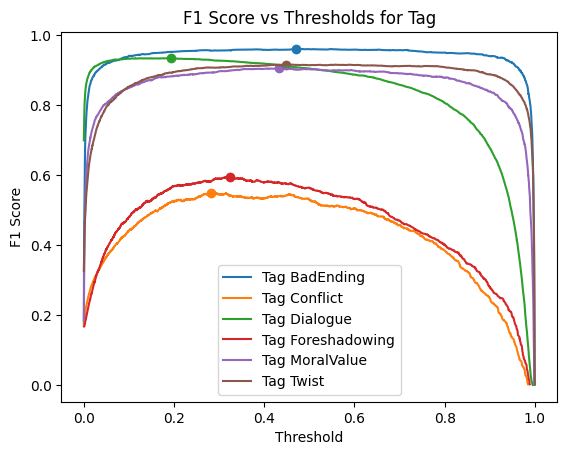

In [ ]:
#function_best_thresholds_with_validation()  #2minutes and a half

In [ ]:
#imports the best_thresholds_tensor from drive, avoiding running the previous function

thresholds_tensor = torch.load('/content/thresholds_tensor.pt')

TEST

In [ ]:
with torch.no_grad():
    all_predicted_labels = []
    all_predicted_probabilities=[]
    batch_size = 32
    for i in range(0, len(test_dataset_1), batch_size):
        batch_inputs_dict = {
            'input_ids': test_dataset_1['input_ids'][i:i+batch_size].to(model_2.device),
            'attention_mask': test_dataset_1['attention_mask'][i:i+batch_size].to(model_2.device),
        }
        outputs = model_2(**batch_inputs_dict)

        logits = outputs.logits

        probabilities = torch.sigmoid(logits)

        all_predicted_probabilities.append(probabilities)
        predicted_labels_batch = (probabilities > thresholds_tensor).int() #transforms the probabilities in a vector of zeros and ones (labels)
        all_predicted_labels.append(predicted_labels_batch)

    predicted_labels = torch.cat(all_predicted_labels, dim=0)

true_tag_lists= test_dataset_1['labels']

In [ ]:
# Initialize dictionaries to store results
def score():
  accuracy_per_tag = {}
  f1_per_tag = {}

  for tag_idx in range(6):
      # Extract true/pred for the current tag
      # Move the tensors to CPU before extracting the column
      y_true_tag = true_tag_lists.cpu()[:, tag_idx]
      y_pred_tag = predicted_labels.cpu()[:, tag_idx]

      # Now passing CPU tensors to scikit-learn functions
      accuracy_per_tag[f"{TAGS[tag_idx]}"] = accuracy_score(y_true_tag, y_pred_tag)
      f1_per_tag[f"{TAGS[tag_idx]}"] = f1_score(y_true_tag, y_pred_tag, zero_division=0)


  # Print overall results
  print("Accuracy for tags:", accuracy_per_tag)
  print("f1_score for tags:", f1_per_tag)
  return accuracy_per_tag, f1_per_tag

#Third Model

We builded a CNN with 3 one dimensional Convolutional layers with decreasing Kernel sizes and ReLU and MaxPool1d activations and finally a Fully Connnected layer with output dimension 6.

In [ ]:
#converting the tokenized datasets into TorchDatasets

def create_datasets(train_dataset, val_dataset):

  train_tokens= train_dataset['input_ids']
  val_tokens = val_dataset['input_ids']

  train_labels = train_dataset['labels']
  val_labels = val_dataset['labels']

  assert len(train_tokens) == len(train_labels)
  assert len(val_tokens) == len(val_labels)

  train_dataset = TensorDataset(train_tokens, train_labels)
  val_dataset = TensorDataset(val_tokens, val_labels)

  return train_dataset, val_dataset

train_dataset_mario, val_dataset_mario= create_datasets(val_dataset_1, val_dataset_1)
prova, test_dataset_mario = create_datasets(test_dataset_1, test_dataset_1)

Here are all the functions used for training, evaluation, computing the metrics and the best thresholds and the class Transpose, used in the model architecture.

In [ ]:
def train(model, train_dataset, val_dataset, optimizer, batch_size, epochs, device, loss_fn):
    model.to(device)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    evaluate(model, val_loader, device, loss_fn, False)

    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}')
        model.train()
        losses = []

        for data, target in train_loader:
            data, target = data.to(device), target.to(device).float()
            optimizer.zero_grad()
            output = model(data)                  # [B,6]
            loss = loss_fn(output, target)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())



        print(f'Train epoch: {epoch + 1} | Train Loss: {np.mean(losses):.4f}')

        evaluate(model, val_loader, device, loss_fn)

def evaluate(model, loader, device, loss_fn, VAL=True):
    model.to(device)
    model.eval()
    total_loss = 0
    correct = 0

    loss_fn = nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device).float()
            output = model(data)
            total_loss += loss_fn(output, target).item()

    average_loss = total_loss / len(loader)
    if VAL:
      print(f'Validation loss: {average_loss:.4f}')
    else:
      print(f'Starting loss: {average_loss:.4f}')
    return average_loss


#we create a function to calculate accuracy and f1-score

def metrics(model, val_dataset, device, batch_size, thresholds=0.5):
    model.to(device)
    model.eval()

    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in val_loader:
            data = data.to(device)
            target = target.to(device).float()

            output = model(data)
            preds = torch.sigmoid(output)
            preds = (preds > thresholds).int()

            all_preds.append(preds.cpu())
            all_targets.append(target.int().cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    num_classes = all_targets.shape[1]
    accuracies = {}
    f1_scores = {}

    for i in range(num_classes):
        acc = accuracy_score(all_targets[:, i], all_preds[:, i])
        f1 = f1_score(all_targets[:, i], all_preds[:, i])
        accuracies[TAGS[i]] = acc
        f1_scores[TAGS[i]] = f1
    print('Accuracy for tags: ',accuracies)
    print('f1_score for tags ',f1_scores)

    return accuracies, f1_scores



def reset_model_weights(model):
    for layer in model.modules():
        if hasattr(layer, 'reset_parameters'):
            layer.reset_parameters()



def threshold_plot(model, val_dataset, device, batch_size=64, thresholds=np.arange(0, 1.0, 0.01), plot=False):
    model.to(device)
    model.eval()

    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in val_loader:
            data = data.to(device)
            target = target.to(device).float()
            output = model(data)
            probs = torch.sigmoid(output)

            all_preds.append(probs.cpu())
            all_targets.append(target.int().cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    num_classes = all_targets.shape[1]
    tag_f1_by_threshold = {tag: [] for tag in TAGS}
    best_thresholds = []

    #calculate F1-score for each thresholds and tags
    for threshold in thresholds:
        for i in range(num_classes):
            preds_thresh = (all_preds[:, i] > threshold).astype(int)
            f1 = f1_score(all_targets[:, i], preds_thresh, zero_division=0)
            tag_f1_by_threshold[TAGS[i]].append(f1)

    # Find the best thresholds
    for tag in TAGS:
        f1s = tag_f1_by_threshold[tag]
        best_idx = np.argmax(f1s)
        best_thresholds.append(thresholds[best_idx])

    # Plot
    if plot:
      plt.figure(figsize=(12, 6))
      for tag in TAGS:
          f1s = tag_f1_by_threshold[tag]
          best_idx = np.argmax(f1s)
          plt.plot(thresholds, f1s, label=f"{tag}")
          plt.scatter(thresholds[best_idx], f1s[best_idx], s=60, zorder=5)

      plt.title("F1 Score per Tag in funzione del Threshold")
      plt.xlabel("Threshold")
      plt.ylabel("F1 Score")
      plt.legend(title="TAG")
      plt.grid(True)
      plt.tight_layout()
      plt.show()

    return torch.tensor(best_thresholds, device=device)

Here is the 2-Branch architecture.

In [ ]:
class MultiBranchCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # Branch 1: small kernels
        self.branch1 = nn.Sequential(
          Transpose(1,2),
          nn.Conv1d(embedding_dim, 2*hidden_dim, kernel_size=3, padding=1),
          nn.ReLU(),
          nn.MaxPool1d(kernel_size=2,stride=2),
          nn.Conv1d(2*hidden_dim, 2*hidden_dim, kernel_size=5, padding=2),
          nn.ReLU(),
          nn.MaxPool1d(kernel_size=5,stride=5),
          nn.Conv1d(2*hidden_dim, 4*hidden_dim, kernel_size=7, padding=3),
          nn.ReLU(),
          nn.AdaptiveMaxPool1d(1), #[batch_size,4*HIDDEN_DIM]
          nn.Flatten()
        )

        # Branch 2: large kernels
        self.branch2 = nn.Sequential(
            Transpose(1, 2),
            nn.Conv1d(embedding_dim, hidden_dim, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(hidden_dim, 2*hidden_dim, kernel_size=11, padding=5),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1),
            nn.Flatten()
        )

        # FC for each subset of classes
        self.fc_local = nn.Sequential(nn.Linear(4*hidden_dim, 64),
                                      nn.ReLU(),
                                      nn.Dropout(0.5),
                                      nn.Linear(64,4)
                                      )  # for BadEnding, dialogue, moralvalue, twist
        self.fc_global = nn.Sequential(nn.Linear(2*hidden_dim, 64),
                                       nn.ReLU(),
                                      nn.Dropout(0.5),
                                      nn.Linear(64,2)
                                      )  # for conflict, foreshadowing

    def forward(self, x):
        x = self.embedding(x)

        out1 = self.branch1(x)
        out2 = self.branch2(x)

        logits_local = self.fc_local(out1)
        logits_global = self.fc_global(out2)

        out = torch.stack([
            logits_local[:, 0],          # badending
            logits_global[:, 0],         # conflict
            logits_local[:, 1],          # dialogue
            logits_global[:, 1],         # foreshadowing
            logits_local[:, 2],          # moralvalue
            logits_local[:, 3],          # twist
        ], dim=1)
        return out


Here is the 1-Branch model, i.e. the best of the two architectures.

In [ ]:
EMBEDDING_DIM=128
HIDDEN_DIM =128
VOCAB_SIZE= len(V)



class Transpose(nn.Module):
    """Swap two tensor dimensions inside a Sequential."""
    def __init__(self, dim0: int, dim1: int):
        super().__init__()
        self.dim0, self.dim1 = dim0, dim1

    def forward(self, x):
        # x is returned as a **view**, so this is zero‑copy
        return x.transpose(self.dim0, self.dim1)




model_3 = nn.Sequential(
    nn.Embedding(VOCAB_SIZE, EMBEDDING_DIM),
    Transpose(1,2),
    nn.Conv1d(EMBEDDING_DIM, 2*HIDDEN_DIM, kernel_size=9, padding=4), #sequence_length = 300
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2,stride=2), #sequence_length = 150
    nn.Conv1d(2*HIDDEN_DIM, 2*HIDDEN_DIM, kernel_size=7, padding=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=5,stride=5), #sequence_lenght = 10
    nn.Conv1d(2*HIDDEN_DIM, 4*HIDDEN_DIM, kernel_size=5, padding=2),
    nn.ReLU(),
    nn.AdaptiveMaxPool1d(1), #[batch_size,4*HIDDEN_DIM]
    nn.Flatten(),
    nn.Dropout(0.5),
    nn.Linear(4*HIDDEN_DIM, 64),
    nn.ReLU(),
    nn.Linear(64, 6)
)

print(f'Number of Parameters: {sum(p.numel() for p in model_3.parameters())}\n')

Number of Parameters: 5350086



Because of the better perfomance of the 1-Branch model we used that one for training and the next cell contains the code that was used to train it.

In [ ]:
if train_running:
  batch_size = 64
  epochs = 2
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  loss_fn = nn.BCEWithLogitsLoss()

  results={}


  reset_model_weights(model_3)

  optimizer = torch.optim.Adam(model_3.parameters(), lr=0.001)

  train(model_3, train_dataset_mario, val_dataset_mario, optimizer, batch_size, epochs, device, loss_fn)

  scores = metrics(model_3, val_dataset_mario, device, batch_size)

In [ ]:
model_3_weights_path = '/content/model_mario_weights.pth'
model_3.load_state_dict(torch.load(model_3_weights_path))


thresholds = threshold_plot(model_3, val_dataset_mario, device)

# Results

Finally, we compared the three models and we observe what is the best

In [ ]:
batch_size = 64
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print('Model 1')
accuracy_per_tag_1, f1_per_tag_1 = scores_1(model_1,X_val,y_val)

print('\nModel 2')
accuracy_per_tag_2,f1_per_tag_2=score()
print('\nModel 3')
accuracy_per_tag_3,f1_per_tag_3= metrics(model_3, test_dataset_mario, device, batch_size, thresholds)



Model 1
Accuracy for tags: {'BadEnding': 0.9751, 'Conflict': 0.8607, 'Dialogue': 0.8627, 'Foreshadowing': 0.8469, 'MoralValue': 0.9655, 'Twist': 0.9419}
f1_score for tags: {'BadEnding': 0.8763040238450075, 'Conflict': 0.4590291262135922, 'Dialogue': 0.8637220843672456, 'Foreshadowing': 0.43401109057301296, 'MoralValue': 0.8441030275643923, 'Twist': 0.8506810588537651}

Model 2
Accuracy for tags: {'BadEnding': 0.9912, 'Conflict': 0.9181, 'Dialogue': 0.9335, 'Foreshadowing': 0.9264, 'MoralValue': 0.9783, 'Twist': 0.9634}
f1_score for tags: {'BadEnding': 0.9519125683060109, 'Conflict': 0.5823559408465069, 'Dialogue': 0.9405984814649397, 'Foreshadowing': 0.5660377358490566, 'MoralValue': 0.8973995271867612, 'Twist': 0.9067753438614365}

Model 3
Accuracy for tags:  {'BadEnding': 0.9868, 'Conflict': 0.8849, 'Dialogue': 0.9108, 'Foreshadowing': 0.8957, 'MoralValue': 0.9727, 'Twist': 0.9511}
f1_score for tags  {'BadEnding': 0.9254237288135593, 'Conflict': 0.44207464857004364, 'Dialogue': 0.922

<Figure size 640x480 with 0 Axes>

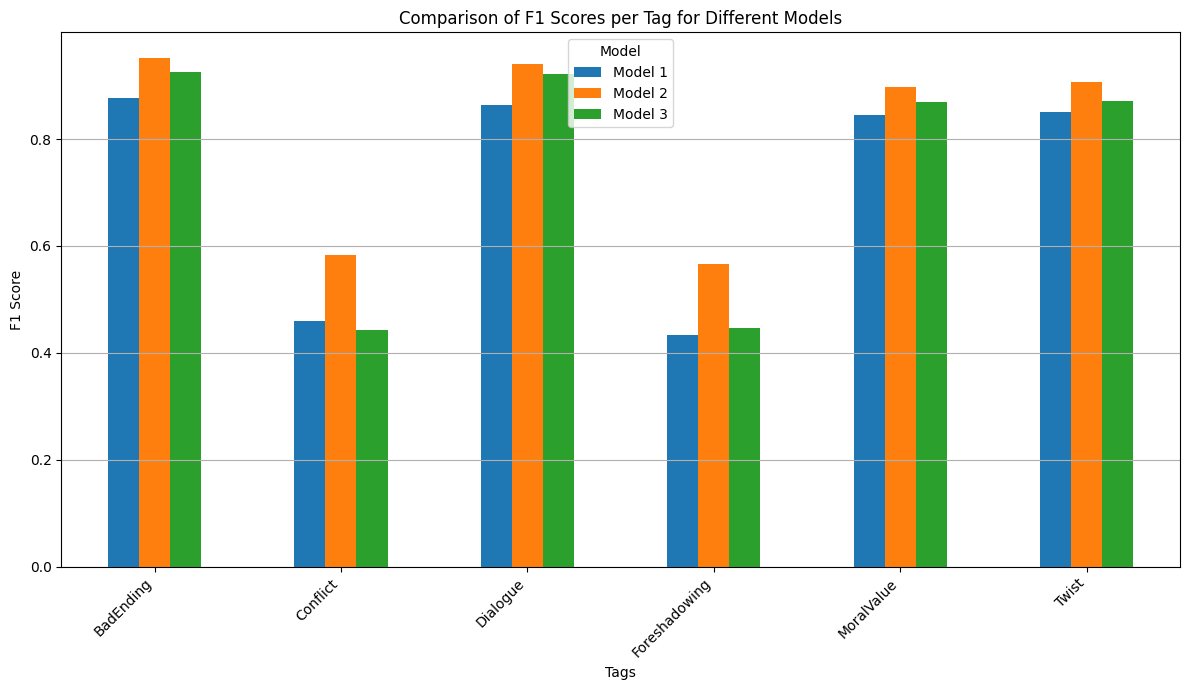

<Figure size 640x480 with 0 Axes>

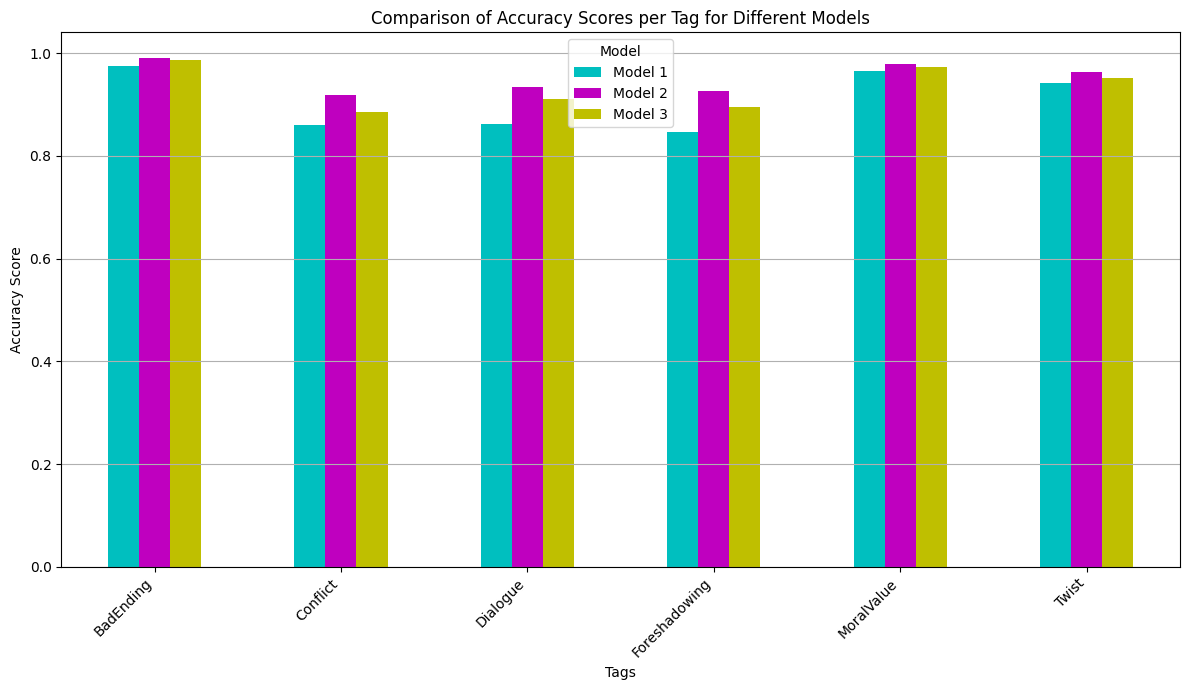

In [ ]:
# Combine the F1 scores into a pandas DataFrame
f1_data = {
    'Model 1': f1_per_tag_1,
    'Model 2': f1_per_tag_2,
    'Model 3': f1_per_tag_3
}
f1_tot = pd.DataFrame(f1_data)
plt.figure(1)
# Plotting the F1 scores
f1_tot.plot(kind='bar', figsize=(12, 7))

plt.title('Comparison of F1 Scores per Tag for Different Models')
plt.xlabel('Tags')
plt.ylabel('F1 Score')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.legend(title='Model')
plt.grid(axis='y')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

# Combine the Accuracy scores into a pandas DataFrame
accuracy_data = {
    'Model 1': accuracy_per_tag_1,
    'Model 2': accuracy_per_tag_2,
    'Model 3': accuracy_per_tag_3
}
accuracy_tot = pd.DataFrame(accuracy_data)


# Plotting the Accuracy scores
plt.figure(2)
accuracy_tot.plot(kind='bar', figsize=(12, 7), color=['c', 'm', 'y'])


plt.title('Comparison of Accuracy Scores per Tag for Different Models')
plt.xlabel('Tags')
plt.ylabel('Accuracy Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model')
plt.grid(axis='y')
plt.tight_layout()
plt.show()